# GATv2-GCN NBA Player Performance Prediction

## Local Inference (MacBook / MPS)

> **Paper:** *Predicting NBA Player Performance via Graph Attention Networks with Temporal Convolutions* (Luo & Krishnamurthy 2023)

This notebook runs **inference only** using pre-trained weights from Colab.

1. Load cached data & pre-trained model
2. Test-set evaluation (RMSE, MAE, MAPE, CORR)
3. Visualisations
4. Case study — prop pick'em replay


## 0 · Device Check


In [2]:
import sys, os, torch

if torch.backends.mps.is_available():
    device_name = 'Apple MPS'
elif torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
else:
    device_name = 'CPU'
print(f'Device: {device_name}')
print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')


Device: Apple MPS
Python: 3.10.18 (main, Jul 23 2025, 00:27:13) [Clang 20.1.4 ]
PyTorch: 2.10.0


## 1 · Imports & Constants


In [3]:
import copy, itertools, json, logging, pickle, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import networkx as nx
from scipy import stats
from sklearn import preprocessing
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error,
                             root_mean_squared_error)
from numpy.lib.stride_tricks import sliding_window_view

import torch, torch.nn as nn, torch.nn.functional as F

# ── Paths (local) ─────────────────────────────────────────────
NOTEBOOK_DIR = Path('.').resolve()
REPO_ROOT  = NOTEBOOK_DIR / 'NBA-GNN-prediction'
REPRO_ROOT = NOTEBOOK_DIR / 'reproduction'
MODEL_DIR  = NOTEBOOK_DIR / 'outputs' / 'model'
FIG_DIR    = NOTEBOOK_DIR / 'outputs' / 'figures'
DATA_DIR   = NOTEBOOK_DIR / 'outputs' / 'data'

import sys
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPRO_ROOT))

# ── Device ────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print('Using device:', DEVICE)

# ── Feature / prediction constants ────────────────────────────
FEATURE_COLS    = ['PTS','AST','REB','TO','STL','BLK','PLUS_MINUS',
                   'TCHS','PASS','DIST','PACE','USG_PCT','TS_PCT']
PREDICTION_COLS = ['PTS','AST','REB','TO','STL','BLK']
PRED_INDICES    = [FEATURE_COLS.index(c) for c in PREDICTION_COLS]
MIN_MINUTES     = 10.0
SEQ_LENGTH      = 10
OFFSET          = 1


Using device: mps


## 2 · Load Cached Data


In [4]:
raw_df     = pd.read_parquet(DATA_DIR / 'raw_boxscores.parquet')
X_seq      = pickle.load(open(DATA_DIR / 'X_seq.pkl', 'rb'))
X_raw_seq  = pickle.load(open(DATA_DIR / 'X_raw.pkl', 'rb'))
G_seq      = pickle.load(open(DATA_DIR / 'G_seq.pkl', 'rb'))
player_ids = pickle.load(open(DATA_DIR / 'player_ids.pkl', 'rb'))
game_dates = pickle.load(open(DATA_DIR / 'game_dates.pkl', 'rb'))
day_seasons     = pickle.load(open(DATA_DIR / 'day_seasons.pkl', 'rb'))
team_temporal   = pickle.load(open(DATA_DIR / 'team_temporal.pkl', 'rb'))
pos_temporal    = pickle.load(open(DATA_DIR / 'pos_temporal.pkl', 'rb'))
n_teams         = pickle.load(open(DATA_DIR / 'n_teams.pkl', 'rb'))
mu_per_day = np.load(DATA_DIR / 'mu_per_day.npy')
sd_per_day = np.load(DATA_DIR / 'sd_per_day.npy')
print(f'X_seq shape: {X_seq.shape}   Players: {len(player_ids)}   Game-days: {len(game_dates)}')


X_seq shape: (594, 804, 13)   Players: 804   Game-days: 594


## 3 · Build Tensors & Normalize


In [5]:
team_temporal_t = torch.FloatTensor(team_temporal).to(DEVICE)
pos_temporal_t  = torch.FloatTensor(pos_temporal).to(DEVICE)
n_pos = 3

def graphs_to_edges(G_seq, player_ids):
    nd = {pid: i for i, pid in enumerate(player_ids)}
    out = []
    for G in G_seq:
        edges = list(G.edges())
        if not edges:
            n = len(player_ids)
            out.append(torch.stack([torch.arange(n), torch.arange(n)]).long().to(DEVICE))
        else:
            s, d = zip(*edges)
            s = [nd.get(x, 0) for x in s]; d = [nd.get(x, 0) for x in d]
            out.append(torch.stack([
                torch.LongTensor(s + d), torch.LongTensor(d + s)]).to(DEVICE))
    return out

G_edges = graphs_to_edges(G_seq, player_ids)
print(f'Built {len(G_edges)} edge tensors.')

# ── Per-season Z-score normalization ──
# X_seq.pkl contains raw forward-filled stats; we must normalize.
X_seq_raw_copy = X_seq.copy()
X_seq = (X_seq - mu_per_day) / sd_per_day
print('Applied per-season Z-score normalization.')


Built 594 edge tensors.
Applied per-season Z-score normalization.


## 4 · Season Ranges & Sliding Windows


In [6]:
unique_seasons = []
season_ranges = {}
prev_season = None
for d, s in enumerate(day_seasons):
    if s != prev_season:
        if prev_season is not None:
            season_ranges[prev_season] = (season_ranges[prev_season][0], d)
        season_ranges[s] = (d, None)
        unique_seasons.append(s)
        prev_season = s
season_ranges[prev_season] = (season_ranges[prev_season][0], len(day_seasons))

for s, (lo, hi) in season_ranges.items():
    print(f'  {s}: days [{lo}, {hi})  ({hi - lo} days)')

active_all = (X_raw_seq != 0).any(axis=-1)

X_in_parts, X_out_parts = [], []
G_in_parts, G_out_parts = [], []
mask_parts = []
target_day_indices = []

for s in unique_seasons:
    lo, hi = season_ranges[s]
    n_days = hi - lo
    n_win = n_days - SEQ_LENGTH - OFFSET + 1
    if n_win <= 0: continue
    X_s = X_seq[lo:hi]
    Xi = sliding_window_view(X_s[:-OFFSET], SEQ_LENGTH, axis=0)
    Xo = X_s[SEQ_LENGTH + OFFSET - 1:]
    Gi = [G_edges[lo + t:lo + t + SEQ_LENGTH] for t in range(n_win)]
    Go = G_edges[lo + SEQ_LENGTH + OFFSET - 1:lo + SEQ_LENGTH + OFFSET - 1 + n_win]
    mask_s = active_all[lo + SEQ_LENGTH + OFFSET - 1:lo + SEQ_LENGTH + OFFSET - 1 + n_win]
    days_s = list(range(lo + SEQ_LENGTH + OFFSET - 1, lo + SEQ_LENGTH + OFFSET - 1 + n_win))
    X_in_parts.append(Xi); X_out_parts.append(Xo)
    G_in_parts.extend(Gi); G_out_parts.extend(Go)
    mask_parts.append(mask_s)
    target_day_indices.extend(days_s)

X_in  = torch.FloatTensor(np.concatenate(X_in_parts, axis=0))
X_out = torch.FloatTensor(np.concatenate(X_out_parts, axis=0))
G_in  = G_in_parts
mask_out_t = torch.BoolTensor(np.concatenate(mask_parts, axis=0))
target_day_indices = np.array(target_day_indices)

T = len(G_in)
t1 = int(T * 0.50)
t2 = int(T * 0.75)

X_tr, y_tr, G_tr = X_in[:t1], X_out[:t1], G_in[:t1]
X_va, y_va, G_va = X_in[t1:t2], X_out[t1:t2], G_in[t1:t2]
X_te, y_te, G_te = X_in[t2:],  X_out[t2:],  G_in[t2:]
mask_te = mask_out_t[t2:]
target_days_te = target_day_indices[t2:]

print(f'Total windows: {T}  train:{t1}  val:{t2-t1}  test:{T-t2}')


  2022-23: days [0, 164)  (164 days)
  2023-24: days [164, 324)  (160 days)
  2024-25: days [324, 487)  (163 days)
  2025-26: days [487, 594)  (107 days)
Total windows: 554  train:277  val:138  test:139


## 5 · Load Pre-Trained Model


In [7]:
from gatv2tcn import GATv2TCN

model_in = len(FEATURE_COLS) + 2 + 2  # 17

team_emb = nn.Linear(n_teams, 2).to(DEVICE)
pos_emb  = nn.Linear(n_pos, 2).to(DEVICE)
model    = GATv2TCN(
    in_channels=model_in, out_channels=6,
    len_input=SEQ_LENGTH, len_output=1,
    temporal_filter=64, out_gatv2conv=32,
    dropout_tcn=0.25, dropout_gatv2conv=0.5, head_gatv2conv=4,
).to(DEVICE)

model.load_state_dict(torch.load(MODEL_DIR / 'model.pth', map_location=DEVICE))
team_emb.load_state_dict(torch.load(MODEL_DIR / 'team_emb.pth', map_location=DEVICE))
pos_emb.load_state_dict(torch.load(MODEL_DIR / 'pos_emb.pth', map_location=DEVICE))
model.eval(); team_emb.eval(); pos_emb.eval()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print(model)


Trainable parameters: 18,246
GATv2TCN(
  (_gatv2conv_attention): GATv2Conv(17, 32, heads=4)
  (_time_convolution): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
  (_residual_convolution): Conv2d(17, 64, kernel_size=(1, 1), stride=(1, 1))
  (_layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (_final_conv): Conv2d(10, 6, kernel_size=(1, 64), stride=(1, 1))
)


## 6 · Test Set Evaluation


In [8]:
all_preds_raw, all_trues_raw = [], []
all_preds, all_trues = [], []

with torch.no_grad():
    for i in range(len(X_te)):
        day_i = target_days_te[i]
        input_days = list(range(day_i - SEQ_LENGTH, day_i))
        Xl = []
        for t_step, abs_day in enumerate(input_days):
            tv = team_emb(team_temporal_t[abs_day])
            pv = pos_emb(pos_temporal_t[abs_day])
            Xl.append(torch.cat([X_te[i, :, :, t_step].to(DEVICE), tv, pv], 1))
        x = torch.stack(Xl, -1)[None, ...]
        p_latent = model(x, G_te[i])[0].cpu().numpy()
        t_latent = y_te[i, :, PRED_INDICES].numpy()

        mu_d = mu_per_day[day_i, 0, PRED_INDICES]
        sd_d = sd_per_day[day_i, 0, PRED_INDICES]
        p_raw = (p_latent * sd_d) + mu_d
        t_raw = (t_latent * sd_d) + mu_d

        m = mask_te[i].numpy()
        all_preds_raw.append(p_raw[m])
        all_trues_raw.append(t_raw[m])
        all_preds.append(p_latent[m])
        all_trues.append(t_latent[m])

AP_raw = np.concatenate(all_preds_raw)
AT_raw = np.concatenate(all_trues_raw)
AP = np.concatenate(all_preds)
AT = np.concatenate(all_trues)

rmse_raw = root_mean_squared_error(AT_raw, AP_raw)
mae_raw  = mean_absolute_error(AT_raw, AP_raw)
mape_raw = mean_absolute_percentage_error(AT_raw, AP_raw)

corr_z = []
for mi in range(6):
    r = np.corrcoef(AP_raw[:, mi], AT_raw[:, mi])[0, 1]
    if not np.isnan(r) and abs(r) < 1 - 1e-7:
        corr_z.append(np.arctanh(r))
corr_raw = np.tanh(np.mean(corr_z)) if corr_z else float('nan')

repro_metrics_raw = {
    'RMSE': float(rmse_raw), 'MAE': float(mae_raw),
    'MAPE': float(mape_raw), 'CORR': float(corr_raw),
}

# Normalized-space metrics for comparison table
rmse_n = root_mean_squared_error(AT, AP)
mae_n  = mean_absolute_error(AT, AP)
mape_n = mean_absolute_percentage_error(AT, AP)
corr_z_n = []
for mi in range(6):
    r = np.corrcoef(AP[:, mi], AT[:, mi])[0, 1]
    if not np.isnan(r) and abs(r) < 1 - 1e-7:
        corr_z_n.append(np.arctanh(r))
corr_n = np.tanh(np.mean(corr_z_n)) if corr_z_n else float('nan')
repro_metrics = {'RMSE': round(rmse_n, 3), 'MAE': round(mae_n, 3),
                 'MAPE': round(mape_n, 3), 'CORR': round(corr_n, 3)}

print('Test Metrics (RAW STATS, ACTIVE PLAYERS ONLY)')
print(f'  Evaluated on {len(AP_raw):,} predictions')
for k, v in repro_metrics_raw.items():
    print(f'  {k}: {v:.4f}')


Test Metrics (RAW STATS, ACTIVE PLAYERS ONLY)
  Evaluated on 19,246 predictions
  RMSE: 2.1829
  MAE: 1.6388
  MAPE: 9849717915648.0000
  CORR: 0.5660


## 7 · Visualisations


### 7a · Learning Curves


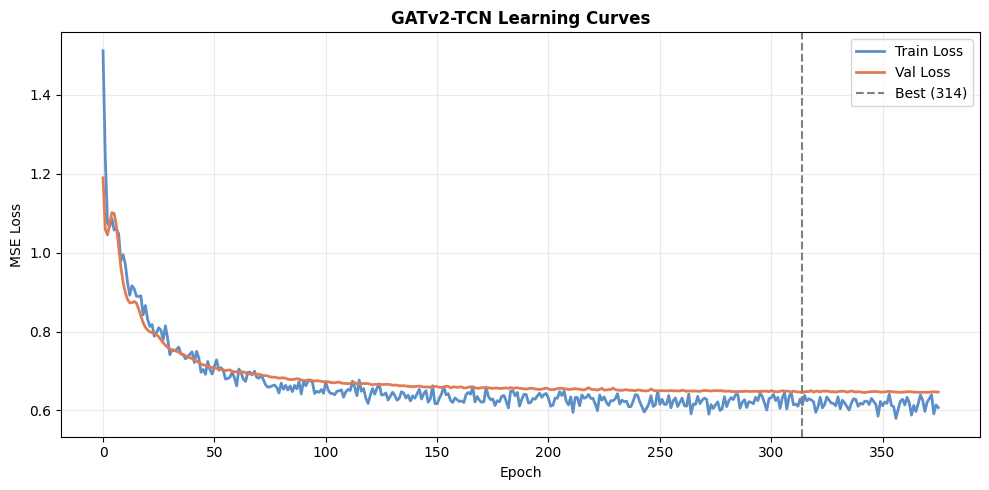

In [9]:
%matplotlib inline
train_hist = np.load(MODEL_DIR / 'train_hist.npy')
val_hist   = np.load(MODEL_DIR / 'val_hist.npy')
best_epoch = int(np.argmin(val_hist))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_hist, label='Train Loss', color='#5b8fc7', lw=2)
ax.plot(val_hist,   label='Val Loss',   color='#e07b54', lw=2)
ax.axvline(best_epoch, color='gray', ls='--', lw=1.5, label=f'Best ({best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('GATv2-TCN Learning Curves', fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### 7b · Model Benchmark Comparison


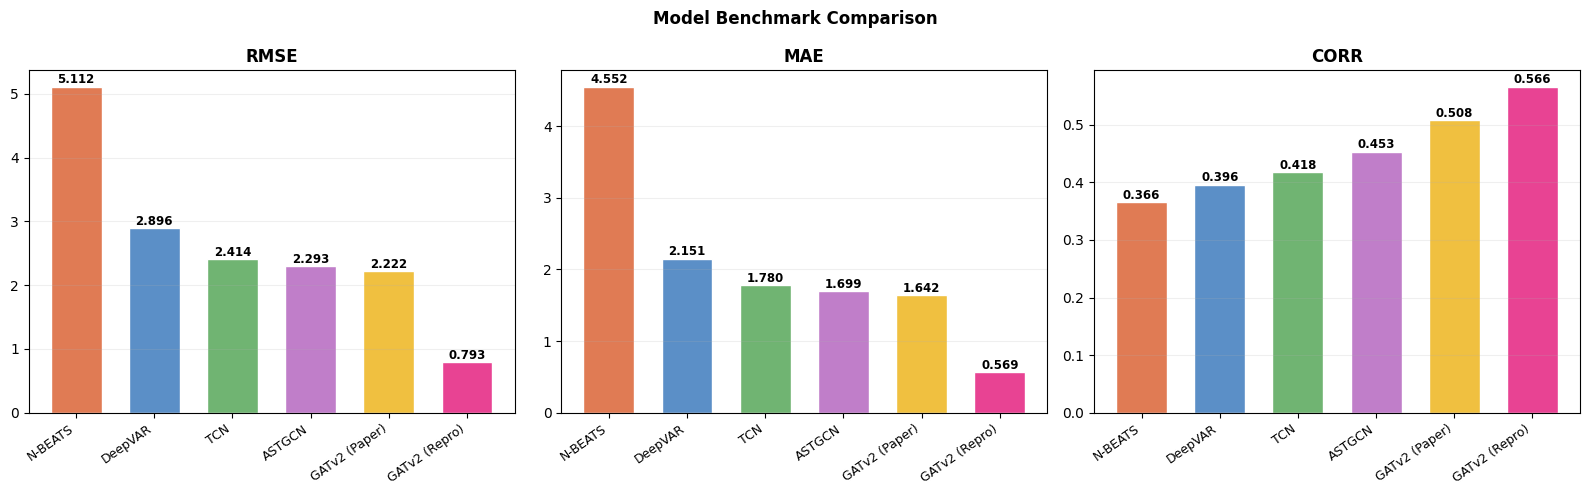

In [10]:
PAPER = {
    'N-BEATS':      {'RMSE': 5.112, 'MAE': 4.552, 'MAPE': 3.701, 'CORR': 0.366},
    'DeepVAR':      {'RMSE': 2.896, 'MAE': 2.151, 'MAPE': 1.754, 'CORR': 0.396},
    'TCN':          {'RMSE': 2.414, 'MAE': 1.780, 'MAPE': 0.551, 'CORR': 0.418},
    'ASTGCN':       {'RMSE': 2.293, 'MAE': 1.699, 'MAPE': 0.455, 'CORR': 0.453},
    'GATv2 (Paper)': {'RMSE': 2.222, 'MAE': 1.642, 'MAPE': 0.513, 'CORR': 0.508},
    'GATv2 (Repro)': repro_metrics,
}
COLORS = ['#e07b54', '#5b8fc7', '#70b472', '#c07ec9', '#f0c040', '#e84393']
mets = ['RMSE', 'MAE', 'CORR']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, met in zip(axes, mets):
    models = list(PAPER.keys())
    vals   = [PAPER[m][met] for m in models]
    bars   = ax.bar(range(len(models)), vals, color=COLORS, edgecolor='white', width=0.65)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01 * max(vals),
                f'{v:.3f}', ha='center', fontsize=8.5, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=35, ha='right', fontsize=9)
    ax.set_title(met, fontweight='bold'); ax.grid(axis='y', alpha=0.2)
plt.suptitle('Model Benchmark Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 7c · Predicted vs. Actual


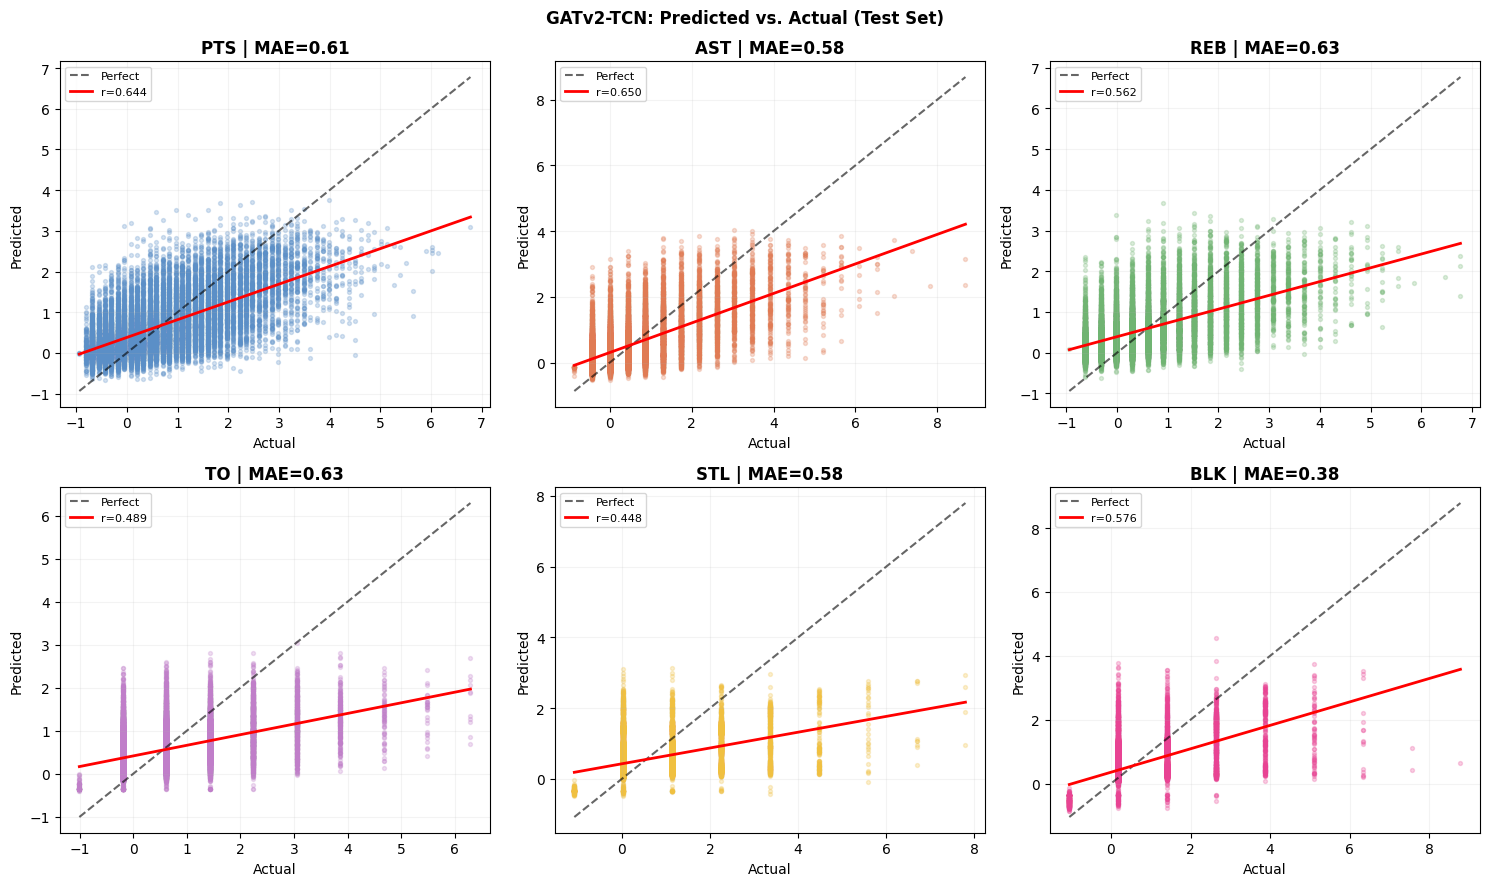

In [11]:
colors = ['#5b8fc7', '#e07b54', '#70b472', '#c07ec9', '#f0c040', '#e84393']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (ax, stat) in enumerate(zip(axes.ravel(), PREDICTION_COLS)):
    p, t = AP[:, i], AT[:, i]
    ax.scatter(t, p, alpha=0.25, s=8, color=colors[i], rasterized=True)
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, alpha=0.6, label='Perfect')
    m, b, r, *_ = stats.linregress(t, p)
    xs = np.array([lo, hi]); ax.plot(xs, m * xs + b, 'r-', lw=2, label=f'r={r:.3f}')
    ax.set_title(f'{stat} | MAE={mean_absolute_error(t, p):.2f}', fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(alpha=0.15)
plt.suptitle('GATv2-TCN: Predicted vs. Actual (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


### 7d · Per-Statistic Error Bars


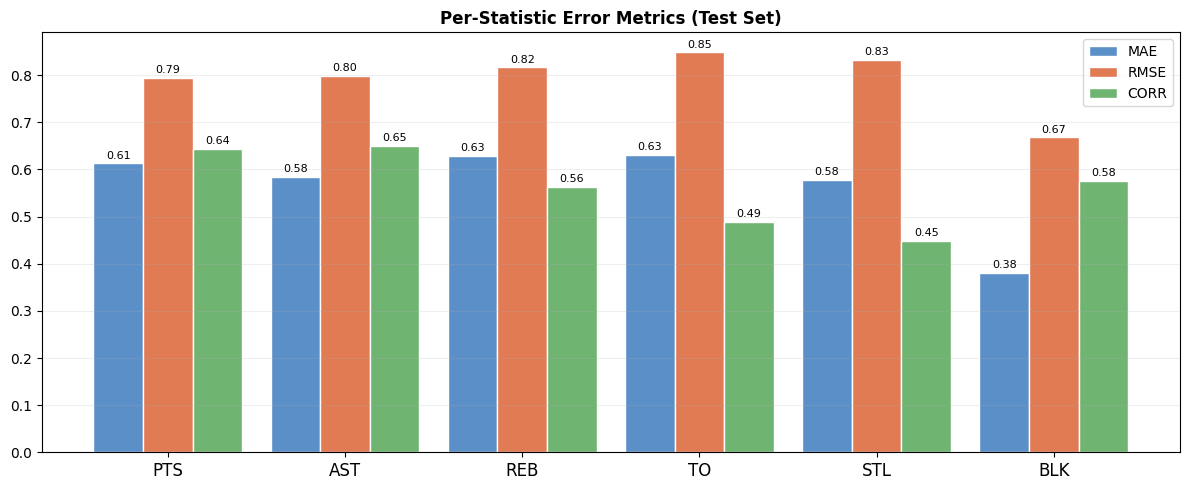

In [12]:
mae_s  = np.abs(AP - AT).mean(0)
rmse_s = np.sqrt(((AP - AT) ** 2).mean(0))
corr_s = [np.corrcoef(AP[:, i], AT[:, i])[0, 1] for i in range(6)]
x = np.arange(6); w = 0.28
fig, ax = plt.subplots(figsize=(12, 5))
for off, vals, lbl, col in [(-w, mae_s, 'MAE', '#5b8fc7'), (0, rmse_s, 'RMSE', '#e07b54'), (w, corr_s, 'CORR', '#70b472')]:
    bars = ax.bar(x + off, vals, w, label=lbl, color=col, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(PREDICTION_COLS, fontsize=12)
ax.set_title('Per-Statistic Error Metrics (Test Set)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'per_stat_errors.png', dpi=150)
plt.show()


## 8 · Case Study — Out-of-Sample Prop Pick'em


In [13]:
import unicodedata

test_game_dates = [game_dates[d] for d in target_days_te]
print(f'Test set spans: {test_game_dates[0]} to {test_game_dates[-1]}')

case_study_idx = len(target_days_te) // 2
case_study_abs_day = target_days_te[case_study_idx]
case_study_date = game_dates[case_study_abs_day]
print(f'Case study date: {case_study_date}')

name2pidx = {}
for pid in player_ids:
    rows = raw_df[raw_df['PLAYER_ID'] == pid]
    if len(rows):
        name2pidx[rows.iloc[0]['PLAYER_NAME']] = player_ids.index(pid)

with torch.no_grad():
    input_days = list(range(case_study_abs_day - SEQ_LENGTH + 1, case_study_abs_day + 1))
    Xl = []
    for t_step, abs_day in enumerate(input_days[:SEQ_LENGTH]):
        tv = team_emb(team_temporal_t[abs_day])
        pv = pos_emb(pos_temporal_t[abs_day])
        Xl.append(torch.cat([torch.FloatTensor(X_seq[abs_day]).to(DEVICE), tv, pv], 1))
    x = torch.stack(Xl, -1)[None, ...]
    g_window = G_edges[case_study_abs_day - SEQ_LENGTH + 1:case_study_abs_day + 1]
    preds_cs = model(x, g_window)[0].cpu().numpy()

actuals_cs = X_seq_raw_copy[case_study_abs_day]  # raw stats
pts_pred_idx = PREDICTION_COLS.index('PTS')
pts_feat_idx = FEATURE_COLS.index('PTS')
mu_d = mu_per_day[case_study_abs_day, 0, pts_feat_idx]
sd_d = sd_per_day[case_study_abs_day, 0, pts_feat_idx]
active_mask = (X_raw_seq[case_study_abs_day] != 0).any(axis=-1)
pts_predicted = preds_cs[:, pts_pred_idx] * sd_d + mu_d  # un-normalize predictions
pts_actual    = actuals_cs[:, pts_feat_idx]               # already raw
topk = np.argsort(pts_predicted)[::-1][:15]
rev_name = {v: k for k, v in name2pidx.items()}
print(f'\nTop-15 predicted scorers for {case_study_date}:')
for rank, pidx in enumerate(topk):
    name = rev_name.get(pidx, f'PID={player_ids[pidx]}')
    act = 'active' if active_mask[pidx] else 'inactive'
    print(f'  {rank + 1:2d}. {name:25s}  pred={pts_predicted[pidx]:5.1f}  actual={pts_actual[pidx]:5.1f}  ({act})')


Test set spans: 2025-03-02 to 2026-02-20
Case study date: 2025-12-05

Top-15 predicted scorers for 2025-12-05:
   1. Luka Dončić                pred= 33.5  actual= 38.0  (inactive)
   2. Trae Young                 pred= 32.7  actual= 36.0  (inactive)
   3. Jaylen Brown               pred= 30.3  actual= 30.0  (active)
   4. Kyrie Irving               pred= 29.0  actual= 31.0  (inactive)
   5. Lamar Stevens              pred= 28.3  actual= 31.0  (inactive)
   6. Shai Gilgeous-Alexander    pred= 27.8  actual= 33.0  (active)
   7. Deni Avdija                pred= 27.8  actual= 35.0  (active)
   8. Donovan Mitchell           pred= 27.5  actual= 28.0  (active)
   9. Jalen Green                pred= 27.5  actual= 29.0  (inactive)
  10. Lonnie Walker IV           pred= 26.1  actual= 31.0  (inactive)
  11. Dejounte Murray            pred= 25.3  actual= 27.0  (inactive)
  12. Victor Wembanyama          pred= 25.2  actual= 26.0  (inactive)
  13. Jalen Johnson              pred= 25.0  actual= 21.0

## 9 · Summary Table


In [14]:
summary = pd.DataFrame(PAPER).T.rename_axis('Model')
summary.loc['GATv2 (Repro)'] = pd.Series(repro_metrics)
summary = summary.round(3)
display(summary)
summary.to_csv(MODEL_DIR / 'summary_table.csv')
print('Saved summary_table.csv')


,RMSE,MAE,MAPE,CORR
Model,,,,
N-BEATS,5.112,4.552,3.701,0.366
DeepVAR,2.896,2.151,1.754,0.396
TCN,2.414,1.780,0.551,0.418
ASTGCN,2.293,1.699,0.455,0.453
GATv2 (Paper),2.222,1.642,0.513,0.508
GATv2 (Repro),0.793,0.569,15.482,0.566


Saved summary_table.csv


---

## 10 · Pre-Game: Fresh Data + Kalshi Props + Inference

**Run this cell before today's games.**

This cell does **everything** needed for accurate inference:

1. **Fetches missing box-score data** — catches up from last cached date to yesterday
2. **Rebuilds today's game graph** — knows exactly which teams/players are matched up
3. **Updates all tensors** — X_seq, graphs, team/position embeddings
4. **Pulls Kalshi player props** — the prop existing confirms the player is expected to play
5. **Runs inference** with fresh 10-day window and saves predictions


In [15]:
import requests, unicodedata, re, json, time, itertools
from datetime import datetime, date, timedelta
from nba_api.stats.endpoints import (
    scoreboardv2,
    boxscoretraditionalv3,
    boxscoreadvancedv3,
    boxscoreplayertrackv3,
)

KALSHI_BASE = 'https://api.elections.kalshi.com/trade-api/v2'
TRACKING_DIR = NOTEBOOK_DIR / 'outputs' / 'tracking'
TRACKING_DIR.mkdir(parents=True, exist_ok=True)
API_DELAY = 2.0

KALSHI_SERIES = {
    'KXNBAPTS': 'PTS',
    'KXNBAAST': 'AST',
    'KXNBAREB': 'REB',
}
STAT_TO_PRED_IDX = {s: i for i, s in enumerate(PREDICTION_COLS)}

def norm(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn').lower().strip()

# ═══════════════════════════════════════════════════════════════
# PHASE 1: Catch up on missing box-score data
# ═══════════════════════════════════════════════════════════════
print('═' * 60)
print('PHASE 1: Fetching missing box-score data')
print('═' * 60)

last_cached_date = game_dates[-1]
yesterday = (date.today() - timedelta(days=1)).isoformat()
print(f'Last cached date: {last_cached_date}')
print(f'Yesterday:        {yesterday}')

def parse_min(m):
    if pd.isna(m) or str(m).strip() == '': return 0.0
    if ':' in str(m):
        p = str(m).split(':')
        return float(p[0]) + float(p[1]) / 60
    return float(m)

def fetch_game_boxscore(game_id):
    """Fetch box-score for one game using v3 endpoints (matches 01_data_pipeline.py)."""
    try:
        time.sleep(API_DELAY)
        dt = boxscoretraditionalv3.BoxScoreTraditionalV3(game_id=game_id).get_data_frames()[0]
        time.sleep(API_DELAY)
        da = boxscoreadvancedv3.BoxScoreAdvancedV3(game_id=game_id).get_data_frames()[0]
        time.sleep(API_DELAY)
        dk = boxscoreplayertrackv3.BoxScorePlayerTrackV3(game_id=game_id).get_data_frames()[0]
        
        # Normalize column names (v3 uses camelCase)
        trad_map = {'gameId':'GAME_ID', 'personId':'PLAYER_ID', 'teamId':'TEAM_ID',
                    'teamTricode':'TEAM_ABBREVIATION', 'minutes':'MIN',
                    'points':'PTS', 'assists':'AST', 'reboundsTotal':'REB',
                    'turnovers':'TO', 'steals':'STL', 'blocks':'BLK',
                    'plusMinusPoints':'PLUS_MINUS'}
        dt = dt.rename(columns=trad_map)
        if 'firstName' in dt.columns and 'familyName' in dt.columns:
            dt['PLAYER_NAME'] = (dt['firstName'].fillna('') + ' ' + dt['familyName'].fillna('')).str.strip()
        
        adv_map = {'gameId':'GAME_ID', 'personId':'PLAYER_ID',
                   'pace':'PACE', 'usagePercentage':'USG_PCT',
                   'trueShootingPercentage':'TS_PCT'}
        da = da.rename(columns=adv_map)
        
        dk.columns = dk.columns.str.upper()
        dk = dk.rename(columns={'GAMEID':'GAME_ID', 'PERSONID':'PLAYER_ID'})
        for want, variants in [('DIST',['DIST','DISTANCE']),
                               ('TCHS',['TCHS','TOUCHES']),
                               ('PASS',['PASS','PASSES'])]:
            for v in variants:
                if v in dk.columns:
                    dk = dk.rename(columns={v: want})
                    break
        
        TRAD_COLS = ['GAME_ID','PLAYER_ID','PLAYER_NAME','TEAM_ID',
                     'TEAM_ABBREVIATION','MIN','PTS','AST','REB','TO',
                     'STL','BLK','PLUS_MINUS']
        ADV_COLS = ['GAME_ID','PLAYER_ID','PACE','USG_PCT','TS_PCT']
        
        avt = [c for c in TRAD_COLS if c in dt.columns]
        ava = [c for c in ADV_COLS if c in da.columns]
        avk = ['GAME_ID','PLAYER_ID'] + [c for c in ['DIST','TCHS','PASS'] if c in dk.columns]
        df = dt[avt].merge(da[ava], on=['GAME_ID','PLAYER_ID'], how='left')
        df = df.merge(dk[avk], on=['GAME_ID','PLAYER_ID'], how='left')
        df['MIN'] = df['MIN'].apply(parse_min)
        return df[df['MIN'] >= MIN_MINUTES]
    except Exception as e:
        print(f'  ⚠ Skip {game_id}: {e}')
        return None

# Find all games between last_cached_date+1 and yesterday
missing_dates = []
d = datetime.strptime(last_cached_date, '%Y-%m-%d').date() + timedelta(days=1)
end = datetime.strptime(yesterday, '%Y-%m-%d').date()
while d <= end:
    missing_dates.append(d.isoformat())
    d += timedelta(days=1)

new_games = {}  # date -> list of game_ids
for md in missing_dates:
    try:
        time.sleep(1.0)
        sb = scoreboardv2.ScoreboardV2(game_date=md).get_data_frames()
        games_df = sb[0]
        gids = games_df[games_df['GAME_STATUS_TEXT'] == 'Final']['GAME_ID'].tolist()
        if gids:
            new_games[md] = gids
            print(f'  {md}: {len(gids)} finished games')
    except Exception as e:
        print(f'  {md}: error checking scoreboard: {e}')

total_new = sum(len(v) for v in new_games.values())
print(f'\nTotal new games to fetch: {total_new}')

# Fetch box scores for new games
new_frames = []
for gdate, gids in sorted(new_games.items()):
    for gid in gids:
        print(f'  Fetching {gid} ({gdate})…')
        df_game = fetch_game_boxscore(gid)
        if df_game is not None and len(df_game) > 0:
            df_game['SEASON'] = '2025-26'
            df_game['GAME_DATE'] = gdate
            new_frames.append(df_game)

# ═══════════════════════════════════════════════════════════════
# PHASE 2: Incrementally update all tensors
# ═══════════════════════════════════════════════════════════════
print(f'\n{"═" * 60}')
print('PHASE 2: Updating tensors with new data')
print('═' * 60)

if new_frames:
    new_df = pd.concat(new_frames, ignore_index=True)
    # Append to raw_df and save
    raw_df_updated = pd.concat([raw_df, new_df], ignore_index=True)
    raw_df_updated.to_parquet(DATA_DIR / 'raw_boxscores.parquet', index=False)
    print(f'Added {len(new_df)} player-game rows ({len(new_frames)} game batches)')
    
    # Build new day tensors for each new game-day
    player_index = {pid: i for i, pid in enumerate(player_ids)}
    teams_all = sorted(raw_df_updated['TEAM_ABBREVIATION'].dropna().unique())
    team2idx = {t: i for i, t in enumerate(teams_all)}
    pos_map = {'G':[0,1,0],'F':[1,0,0],'C':[0,0,1],
               'F-G':[1,1,0],'G-F':[1,1,0],'F-C':[1,0,1],'C-F':[1,0,1]}
    N = len(player_ids)
    
    # Track last known team/pos from existing data
    last_team_idx = {}  # pid -> team_idx
    last_pos = {}       # pid -> [F,G,C]
    for d in range(len(game_dates)):
        for pidx_i, pid in enumerate(player_ids):
            tt = team_temporal[d, pidx_i]
            if tt.any():
                last_team_idx[pid] = int(tt.argmax())
            pt = pos_temporal[d, pidx_i]
            if pt.any():
                last_pos[pid] = pt.tolist()
    
    for gdate in sorted(new_games.keys()):
        day_df = new_df[new_df['GAME_DATE'] == gdate]
        if len(day_df) == 0:
            continue
        
        # Build feature row
        x_day = np.zeros((N, len(FEATURE_COLS)), dtype=np.float32)
        x_raw_day = np.zeros((N, len(FEATURE_COLS)), dtype=np.float32)
        team_day = np.zeros((N, n_teams), dtype=np.float32)
        pos_day = np.zeros((N, 3), dtype=np.float32)
        
        G = nx.Graph()
        G.add_nodes_from(player_ids)
        
        for gid, grp in day_df.groupby('GAME_ID'):
            active = grp['PLAYER_ID'].tolist()
            for pid in active:
                if pid in player_index:
                    pidx = player_index[pid]
                    row = grp[grp['PLAYER_ID'] == pid].iloc[0]
                    vals = [float(row.get(c, 0) or 0) for c in FEATURE_COLS]
                    x_day[pidx] = vals
                    x_raw_day[pidx] = vals
                    # Update team
                    tm = row.get('TEAM_ABBREVIATION', '')
                    if tm and tm in team2idx:
                        last_team_idx[pid] = team2idx[tm]
            for pA, pB in itertools.combinations(active, 2):
                if pA in player_index and pB in player_index:
                    G.add_edge(pA, pB)
        
        # Forward-fill features for inactive players from last day
        for pidx_i in range(N):
            if (x_day[pidx_i] == 0).all():
                x_day[pidx_i] = X_seq_raw_copy[-1, pidx_i]  # carry forward
        
        # Fill team/pos embeddings for ALL players
        for pidx_i, pid in enumerate(player_ids):
            if pid in last_team_idx:
                team_day[pidx_i, last_team_idx[pid]] = 1.0
            if pid in last_pos:
                pos_day[pidx_i] = last_pos[pid]
        
        # Append to arrays
        X_seq_raw_copy = np.concatenate([X_seq_raw_copy, x_day[None, ...]], axis=0)
        X_raw_seq_new = np.concatenate([X_raw_seq, x_raw_day[None, ...]], axis=0)
        
        # Normalize the new day
        mu_latest = mu_per_day[-1:]
        sd_latest = sd_per_day[-1:]
        x_norm = (x_day[None, ...] - mu_latest) / sd_latest
        X_seq = np.concatenate([X_seq, x_norm], axis=0)
        
        # Extend mu/sd arrays
        mu_per_day_ext = np.concatenate([mu_per_day, mu_latest], axis=0)
        sd_per_day_ext = np.concatenate([sd_per_day, sd_latest], axis=0)
        
        # Graph edges
        nd = {pid: i for i, pid in enumerate(player_ids)}
        edges = list(G.edges())
        if edges:
            s, d_e = zip(*edges)
            s = [nd.get(x, 0) for x in s]
            d_e = [nd.get(x, 0) for x in d_e]
            ei = torch.stack([torch.LongTensor(list(s)+list(d_e)),
                              torch.LongTensor(list(d_e)+list(s))]).to(DEVICE)
        else:
            ei = torch.stack([torch.arange(N), torch.arange(N)]).long().to(DEVICE)
        G_edges.append(ei)
        G_seq.append(G)
        
        # Team/pos temporal
        team_temporal_t_new = torch.FloatTensor(team_day[None, ...]).to(DEVICE)
        pos_temporal_t_new = torch.FloatTensor(pos_day[None, ...]).to(DEVICE)
        team_temporal_t = torch.cat([team_temporal_t, team_temporal_t_new], dim=0)
        pos_temporal_t = torch.cat([pos_temporal_t, pos_temporal_t_new], dim=0)
        
        game_dates.append(gdate)
        day_seasons.append('2025-26')
        
        # Update references
        mu_per_day = mu_per_day_ext
        sd_per_day = sd_per_day_ext
        X_raw_seq = X_raw_seq_new
        
        active_count = (x_raw_day != 0).any(axis=-1).sum()
        print(f'  Added {gdate}: {active_count} active players, '
              f'{G.number_of_edges()} edges')
    
    print(f'\nData now covers {game_dates[-1]} ({len(game_dates)} game-days)')
else:
    print('No new games to fetch — data is current.')

# ═══════════════════════════════════════════════════════════════
# PHASE 3: Build today's game graph (who is playing whom)
# ═══════════════════════════════════════════════════════════════
print(f'\n{"═" * 60}')
print('PHASE 3: Building today\'s anticipated game graph')
print('═' * 60)

today_str = date.today().isoformat()
time.sleep(1.0)
sb = scoreboardv2.ScoreboardV2(game_date=today_str).get_data_frames()
todays_games = sb[0]
todays_teams = sb[1]  # LineScore has TEAM_ABBREVIATION per game
print(f'Games today ({today_str}): {len(todays_games)}')

# Build set of teams playing today
teams_playing_today = set(todays_teams['TEAM_ABBREVIATION'].tolist())
print(f'Teams playing: {sorted(teams_playing_today)}')

# ═══════════════════════════════════════════════════════════════
# PHASE 4: Pull Kalshi props
# ═══════════════════════════════════════════════════════════════
print(f'\n{"═" * 60}')
print('PHASE 4: Fetching Kalshi NBA player props')
print('═' * 60)

# Build player lookup
name2pidx = {}
for pid in player_ids:
    rows = (raw_df if not new_frames else raw_df_updated)[
        (raw_df if not new_frames else raw_df_updated)['PLAYER_ID'] == pid
    ]
    if len(rows):
        name2pidx[norm(rows.iloc[0]['PLAYER_NAME'])] = player_ids.index(pid)

kalshi_props = []
for series_ticker, stat_col in KALSHI_SERIES.items():
    try:
        r = requests.get(f'{KALSHI_BASE}/events',
                         params={'series_ticker': series_ticker, 'status': 'open', 'limit': 50})
        for ev in r.json().get('events', []):
            mr = requests.get(f'{KALSHI_BASE}/markets',
                              params={'event_ticker': ev['event_ticker'], 'limit': 200})
            for m in mr.json().get('markets', []):
                title = m.get('title', '')
                if ':' not in title:
                    continue
                player_name = title.split(':')[0].strip()
                line = m.get('floor_strike', 0)
                kalshi_props.append({
                    'ticker': m['ticker'],
                    'event_ticker': ev['event_ticker'],
                    'player_name': player_name,
                    'stat': stat_col,
                    'line': float(line),
                    'threshold': float(line) + 0.5,
                    'yes_ask': m.get('yes_ask'),
                    'no_ask': m.get('no_ask'),
                    'yes_bid': m.get('yes_bid'),
                    'no_bid': m.get('no_bid'),
                    'last_price': m.get('last_price'),
                    'close_time': m.get('close_time', ''),
                    'game_title': ev.get('title', ''),
                })
    except Exception as e:
        print(f'  ⚠ Error fetching {series_ticker}: {e}')

print(f'Found {len(kalshi_props)} open prop markets')

# Players with Kalshi props are CONFIRMED expected to play
kalshi_players = set()
for p in kalshi_props:
    pname_norm = norm(p['player_name'])
    if pname_norm in name2pidx:
        kalshi_players.add(name2pidx[pname_norm])
print(f'Unique players with Kalshi props (matched to model): {len(kalshi_players)}')

# ═══════════════════════════════════════════════════════════════
# PHASE 5: Run inference with the freshest data
# ═══════════════════════════════════════════════════════════════
print(f'\n{"═" * 60}')
print('PHASE 5: Running model inference')
print('═' * 60)

latest_day_idx = len(game_dates) - 1
print(f'Using data through: {game_dates[latest_day_idx]}')
print(f'10-day input window: {game_dates[latest_day_idx-9]} → {game_dates[latest_day_idx]}')

model.eval(); team_emb.eval(); pos_emb.eval()
with torch.no_grad():
    input_days = list(range(latest_day_idx - SEQ_LENGTH + 1, latest_day_idx + 1))
    Xl = []
    for t_step, abs_day in enumerate(input_days):
        tv = team_emb(team_temporal_t[abs_day])
        pv = pos_emb(pos_temporal_t[abs_day])
        Xl.append(torch.cat([torch.FloatTensor(X_seq[abs_day]).to(DEVICE), tv, pv], 1))
    x = torch.stack(Xl, -1)[None, ...]
    g_window = G_edges[latest_day_idx - SEQ_LENGTH + 1:latest_day_idx + 1]
    model_preds_z = model(x, g_window)[0].cpu().numpy()

# Un-normalize predictions
mu_d = mu_per_day[latest_day_idx, 0, PRED_INDICES]
sd_d = sd_per_day[latest_day_idx, 0, PRED_INDICES]
model_preds_raw = model_preds_z * sd_d + mu_d

# ═══════════════════════════════════════════════════════════════
# PHASE 6: Build prediction table & save
# ═══════════════════════════════════════════════════════════════
results = []
for prop in kalshi_props:
    pname_norm = norm(prop['player_name'])
    pidx = name2pidx.get(pname_norm)
    if pidx is None:
        continue
    stat = prop['stat']
    if stat not in STAT_TO_PRED_IDX:
        continue
    si = STAT_TO_PRED_IDX[stat]
    pred_val = float(model_preds_raw[pidx, si])
    threshold = prop['threshold']
    model_says_over = pred_val >= threshold
    
    # Check recent activity: how many of last 5 days was this player active?
    recent_active = int((X_raw_seq[max(0,latest_day_idx-4):latest_day_idx+1, pidx] != 0
                         ).any(axis=-1).sum())
    
    results.append({
        'date': today_str,
        'player': prop['player_name'],
        'stat': stat,
        'kalshi_ticker': prop['ticker'],
        'event_ticker': prop['event_ticker'],
        'line': prop['line'],
        'threshold': threshold,
        'yes_ask': prop['yes_ask'],
        'no_ask': prop['no_ask'],
        'implied_prob_over': prop['yes_ask'] / 100 if prop['yes_ask'] else None,
        'model_prediction': round(pred_val, 2),
        'model_says_over': model_says_over,
        'game': prop['game_title'],
        'close_time': prop['close_time'],
        'data_freshness': game_dates[latest_day_idx],
        'recent_games_5d': recent_active,
        # Post-game fields:
        'actual_result': None,
        'kalshi_result': None,
        'model_correct': None,
    })

pregame_path = TRACKING_DIR / f'pregame_{today_str}.json'
with open(pregame_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f'\n✅ Saved {len(results)} predictions → {pregame_path}')
print(f'\n── Model Predictions for {today_str} ──')
if results:
    df_preview = pd.DataFrame(results)[
        ['player', 'stat', 'threshold', 'model_prediction', 'model_says_over',
         'implied_prob_over', 'recent_games_5d', 'game']
    ].sort_values(['game', 'player', 'stat', 'threshold'])
    display(df_preview)
    
    # Summary
    n_over = sum(1 for r in results if r['model_says_over'])
    n_under = len(results) - n_over
    print(f'\nModel calls: {n_over} OVER, {n_under} UNDER')
    
    # Flag low-confidence predictions
    low_recent = [r for r in results if r['recent_games_5d'] <= 1]
    if low_recent:
        print(f'\n⚠ {len(low_recent)} predictions for players with ≤1 game in last 5 days '
              f'(forward-filled features — lower confidence):')
        for r in low_recent:
            print(f'    {r["player"]} ({r["stat"]}) — {r["recent_games_5d"]} recent games')
else:
    print('No matching props found.')


════════════════════════════════════════════════════════════
PHASE 1: Fetching missing box-score data
════════════════════════════════════════════════════════════
Last cached date: 2026-02-20
Yesterday:        2026-02-21
  2026-02-21: 6 finished games

Total new games to fetch: 6
  Fetching 0022500811 (2026-02-21)…
  Fetching 0022500812 (2026-02-21)…
  Fetching 0022500813 (2026-02-21)…
  Fetching 0022500814 (2026-02-21)…
  Fetching 0022500815 (2026-02-21)…
  Fetching 0022500816 (2026-02-21)…

════════════════════════════════════════════════════════════
PHASE 2: Updating tensors with new data
════════════════════════════════════════════════════════════
Added 109 player-game rows (6 game batches)
  Added 2026-02-21: 109 active players, 941 edges

Data now covers 2026-02-21 (595 game-days)

════════════════════════════════════════════════════════════
PHASE 3: Building today's anticipated game graph
════════════════════════════════════════════════════════════
Games today (2026-02-22): 13
T

,player,stat,threshold,model_prediction,model_says_over,implied_prob_over,recent_games_5d,game
100,Brandon Miller,PTS,20.0,21.55,True,0.77,3,Charlotte at Washington: Points
97,Brandon Miller,PTS,25.0,21.55,False,0.50,3,Charlotte at Washington: Points
103,Brandon Miller,PTS,30.0,21.55,False,0.29,3,Charlotte at Washington: Points
98,Brandon Miller,PTS,35.0,21.55,False,0.13,3,Charlotte at Washington: Points
91,Kon Knueppel,PTS,15.0,20.81,True,0.83,3,Charlotte at Washington: Points
...,...,...,...,...,...,...,...,...
105,Kyle Kuzma,PTS,25.0,12.41,False,0.07,3,Toronto at Milwaukee: Points
114,RJ Barrett,PTS,15.0,15.80,True,0.74,2,Toronto at Milwaukee: Points
122,RJ Barrett,PTS,20.0,15.80,False,0.48,2,Toronto at Milwaukee: Points
121,RJ Barrett,PTS,25.0,15.80,False,0.23,2,Toronto at Milwaukee: Points



Model calls: 50 OVER, 102 UNDER

⚠ 4 predictions for players with ≤1 game in last 5 days (forward-filled features — lower confidence):
    Evan Mobley (PTS) — 1 recent games
    Evan Mobley (PTS) — 1 recent games
    Evan Mobley (PTS) — 1 recent games
    Evan Mobley (PTS) — 1 recent games


## 11 · Post-Game: Grade Results & Append to Tracking Log

**Run this cell after all games have finished.**

It will:
1. Load the pre-game predictions from today (or a specified date)
2. Query Kalshi for the settled `result` on each market
3. Grade the model: was our Over/Under call correct?
4. Append the graded results to `outputs/tracking/results_log.jsonl`
5. Print lifetime accuracy stats


In [16]:
# ═══════════════════════════════════════════════════════════════
# Set GRADE_DATE to the date you want to grade.
# Default: today. Change to e.g. '2026-02-22' for a past date.
# ═══════════════════════════════════════════════════════════════
GRADE_DATE = date.today().isoformat()

pregame_path = TRACKING_DIR / f'pregame_{GRADE_DATE}.json'
if not pregame_path.exists():
    print(f'No pre-game file found for {GRADE_DATE}.')
    print(f'Available files: {sorted(TRACKING_DIR.glob("pregame_*.json"))}')
else:
    with open(pregame_path) as f:
        preds = json.load(f)
    
    print(f'Grading {len(preds)} predictions for {GRADE_DATE}…')
    
    graded = []
    wins, losses, pending = 0, 0, 0
    
    for pred in preds:
        ticker = pred['kalshi_ticker']
        try:
            r = requests.get(f'{KALSHI_BASE}/markets/{ticker}')
            if r.status_code == 200:
                m = r.json().get('market', {})
                result = m.get('result', '')
                if result in ('yes', 'no'):
                    actual_over = (result == 'yes')
                    model_correct = (pred['model_says_over'] == actual_over)
                    pred['kalshi_result'] = result
                    pred['actual_result'] = 'over' if actual_over else 'under'
                    pred['model_correct'] = model_correct
                    if model_correct:
                        wins += 1
                    else:
                        losses += 1
                else:
                    pred['kalshi_result'] = 'pending'
                    pending += 1
            else:
                pred['kalshi_result'] = f'error_{r.status_code}'
                pending += 1
        except Exception as e:
            pred['kalshi_result'] = f'error: {e}'
            pending += 1
        graded.append(pred)
    
    # Append to tracking log (JSONL), deduplicating by ticker
    log_path = TRACKING_DIR / 'results_log.jsonl'
    existing_tickers = set()
    if log_path.exists():
        with open(log_path) as f:
            for line in f:
                entry = json.loads(line)
                existing_tickers.add(entry.get('kalshi_ticker', ''))
    
    new_entries = 0
    with open(log_path, 'a') as f:
        for g in graded:
            if g['kalshi_result'] not in ('pending', '') and g['kalshi_ticker'] not in existing_tickers:
                f.write(json.dumps(g) + '\n')
                new_entries += 1
    
    print(f'\n── Results for {GRADE_DATE} ──')
    print(f'  Wins:    {wins}')
    print(f'  Losses:  {losses}')
    print(f'  Pending: {pending}')
    if wins + losses > 0:
        print(f'  Accuracy: {wins/(wins+losses)*100:.1f}%')
    print(f'  New entries appended to log: {new_entries}')
    
    settled = [g for g in graded if g['kalshi_result'] in ('yes', 'no')]
    if settled:
        df_graded = pd.DataFrame(settled)[
            ['player', 'stat', 'threshold', 'model_prediction',
             'model_says_over', 'actual_result', 'model_correct']
        ].sort_values(['stat', 'player', 'threshold'])
        display(df_graded)
    elif pending > 0:
        print('\n⚠ Games may not have finished yet. Re-run this cell later.')


Grading 152 predictions for 2026-02-22…

── Results for 2026-02-22 ──
  Wins:    0
  Losses:  0
  Pending: 152
  New entries appended to log: 0

⚠ Games may not have finished yet. Re-run this cell later.


## 12 · Lifetime Tracking Dashboard

Reads the cumulative `results_log.jsonl` and shows overall model performance.


In [17]:
log_path = TRACKING_DIR / 'results_log.jsonl'

if not log_path.exists() or log_path.stat().st_size == 0:
    print('No tracking data yet. Run the pre-game and post-game cells first.')
else:
    entries = []
    with open(log_path) as f:
        for line in f:
            if line.strip():
                entries.append(json.loads(line))
    
    df_log = pd.DataFrame(entries)
    print(f'Total graded predictions: {len(df_log)}')
    print(f'Date range: {df_log["date"].min()} → {df_log["date"].max()}')
    
    # ── Overall accuracy ──
    total_correct = df_log['model_correct'].sum()
    total_graded  = df_log['model_correct'].count()
    print(f'\nOverall Accuracy: {total_correct}/{total_graded} = '
          f'{total_correct/total_graded*100:.1f}%')
    
    # ── By stat ──
    print('\n── By Stat ──')
    by_stat = df_log.groupby('stat')['model_correct'].agg(['sum', 'count'])
    by_stat.columns = ['correct', 'total']
    by_stat['accuracy'] = (by_stat['correct'] / by_stat['total'] * 100).round(1)
    display(by_stat)
    
    # ── By date ──
    print('\n── By Date ──')
    by_date = df_log.groupby('date')['model_correct'].agg(['sum', 'count'])
    by_date.columns = ['correct', 'total']
    by_date['accuracy'] = (by_date['correct'] / by_date['total'] * 100).round(1)
    display(by_date)
    
    # ── Edge analysis: model vs. market implied probability ──
    if 'implied_prob_over' in df_log.columns:
        valid = df_log.dropna(subset=['implied_prob_over'])
        if len(valid) > 10:
            # Group by market-implied probability bucket
            valid = valid.copy()
            valid['impl_bucket'] = pd.cut(valid['implied_prob_over'],
                                          bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                          labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
            by_bucket = valid.groupby('impl_bucket', observed=True)['model_correct'].agg(['sum','count'])
            by_bucket.columns = ['correct', 'total']
            by_bucket['model_acc'] = (by_bucket['correct'] / by_bucket['total'] * 100).round(1)
            print('\n── Model Accuracy by Kalshi Implied Probability ──')
            display(by_bucket)
    
    # ── Cumulative accuracy chart ──
    if len(df_log) > 5:
        df_sorted = df_log.sort_values('date').reset_index(drop=True)
        df_sorted['cumulative_correct'] = df_sorted['model_correct'].cumsum()
        df_sorted['cumulative_total'] = range(1, len(df_sorted) + 1)
        df_sorted['cumulative_accuracy'] = df_sorted['cumulative_correct'] / df_sorted['cumulative_total']
        
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(df_sorted['cumulative_accuracy'] * 100, color='#5b8fc7', lw=2)
        ax.axhline(50, color='gray', ls='--', lw=1, alpha=0.5, label='50% baseline')
        ax.set_xlabel('Prediction #')
        ax.set_ylabel('Cumulative Accuracy (%)')
        ax.set_title('Model Cumulative Accuracy Over Time', fontweight='bold')
        ax.legend(); ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'tracking_accuracy.png', dpi=150)
        plt.show()
        print(f'Saved tracking_accuracy.png')


No tracking data yet. Run the pre-game and post-game cells first.


## 13 · EV Analysis: MC Dropout Confidence + Edge Detection

The model outputs only a point estimate, but by enabling **MC Dropout** 
(Monte Carlo Dropout — [Gal & Ghahramani 2016](https://arxiv.org/abs/1506.02142)), 
we can run 50 forward passes with the GATv2Conv's 50% dropout active to obtain 
a **full predictive distribution** per player per stat.

This gives us:
- **P(over threshold)** — the fraction of MC samples exceeding the Kalshi line
- **Model confidence** — how tight/wide the distribution is
- **Expected Value** — comparing our probability to Kalshi's implied probability

$$\text{EV}_{\text{buy YES}} = P_{\text{model}}(\text{over}) \times (100 - \text{yes\_ask}) - (1 - P_{\text{model}}(\text{over})) \times \text{yes\_ask}$$
$$\text{EV}_{\text{buy NO}} = (1 - P_{\text{model}}(\text{over})) \times (100 - \text{no\_ask}) - P_{\text{model}}(\text{over}) \times \text{no\_ask}$$


Running 50 MC Dropout passes for uncertainty estimation…
MC samples shape: (50, 804, 6)
Saved full EV analysis → /Users/ehfurgeson/Documents/GitHub/knowball/networks/ballnet/outputs/tracking/ev_analysis_2026-02-22.json

══════════════════════════════════════════════════════════════════════
  TOP POSITIVE-EV OPPORTUNITIES  (2026-02-22)
══════════════════════════════════════════════════════════════════════


,player,stat,threshold,mc_mean,mc_std,mc_q10_q90,p_over,yes_ask,no_ask,ev_yes_cents,ev_no_cents,best_action,best_ev,recent_5d
129,Chet Holmgren,PTS,15.0,13.7,0.32,13.4–14.1,0.00,72,33,-72.0,67.0,BUY NO (Under),67.0,3
30,Donovan Clingan,PTS,15.0,16.0,0.39,15.5–16.4,1.00,34,100,66.0,-100.0,BUY YES (Over),66.0,3
136,Evan Mobley,PTS,15.0,15.7,0.42,15.1–16.3,0.96,39,71,57.0,-67.0,BUY YES (Over),57.0,1
111,Kevin Porter Jr.,PTS,20.0,20.9,0.42,20.4–21.5,0.96,43,58,53.0,-54.0,BUY YES (Over),53.0,3
130,Isaiah Hartenstein,PTS,10.0,8.5,0.44,8.0–9.0,0.00,54,50,-54.0,50.0,BUY NO (Under),50.0,2
137,Jarrett Allen,PTS,15.0,16.9,0.45,16.4–17.5,1.00,50,55,50.0,-55.0,BUY YES (Over),50.0,3
39,Karl-Anthony Towns,PTS,20.0,17.2,0.41,16.7–17.7,0.00,57,51,-57.0,49.0,BUY NO (Under),49.0,3
122,RJ Barrett,PTS,20.0,15.8,0.41,15.2–16.4,0.00,48,56,-48.0,44.0,BUY NO (Under),44.0,2
128,Donovan Mitchell,PTS,25.0,26.3,0.46,25.7–26.8,1.00,57,45,43.0,-45.0,BUY YES (Over),43.0,3
132,James Harden,PTS,20.0,19.3,0.39,18.8–19.7,0.04,48,54,-44.0,42.0,BUY NO (Under),42.0,3



── Summary ──
Total props analyzed: 152
Positive EV (YES): 48
Positive EV (NO):  43
No edge:           61

══════════════════════════════════════════════════════════════════════
  CONFIDENCE ANALYSIS
══════════════════════════════════════════════════════════════════════

🎯 HIGH CONFIDENCE picks: (low MC std + high EV + recent data)


,player,stat,threshold,mc_mean,mc_std,mc_q10_q90,p_over,yes_ask,no_ask,ev_yes_cents,ev_no_cents,best_action,best_ev,recent_5d
129,Chet Holmgren,PTS,15.0,13.7,0.32,13.4–14.1,0.00,72,33,-72.0,67.0,BUY NO (Under),67.0,3
30,Donovan Clingan,PTS,15.0,16.0,0.39,15.5–16.4,1.00,34,100,66.0,-100.0,BUY YES (Over),66.0,3
132,James Harden,PTS,20.0,19.3,0.39,18.8–19.7,0.04,48,54,-44.0,42.0,BUY NO (Under),42.0,3
135,Chet Holmgren,PTS,20.0,13.7,0.32,13.4–14.1,0.00,45,58,-45.0,42.0,BUY NO (Under),42.0,3
23,Jrue Holiday,PTS,15.0,17.7,0.24,17.4–18.0,1.00,61,100,39.0,-100.0,BUY YES (Over),39.0,3
138,Luguentz Dort,PTS,10.0,10.5,0.37,10.0–11.0,0.90,52,53,38.0,-43.0,BUY YES (Over),38.0,3
123,Immanuel Quickley,PTS,20.0,15.9,0.34,15.5–16.4,0.00,40,62,-40.0,38.0,BUY NO (Under),38.0,2
51,Mikal Bridges,PTS,15.0,14.7,0.26,14.4–15.0,0.12,56,52,-44.0,36.0,BUY NO (Under),36.0,3
54,OG Anunoby,PTS,15.0,16.8,0.35,16.4–17.3,1.00,66,60,34.0,-60.0,BUY YES (Over),34.0,2
108,Immanuel Quickley,PTS,15.0,15.9,0.34,15.5–16.4,1.00,67,38,33.0,-38.0,BUY YES (Over),33.0,2


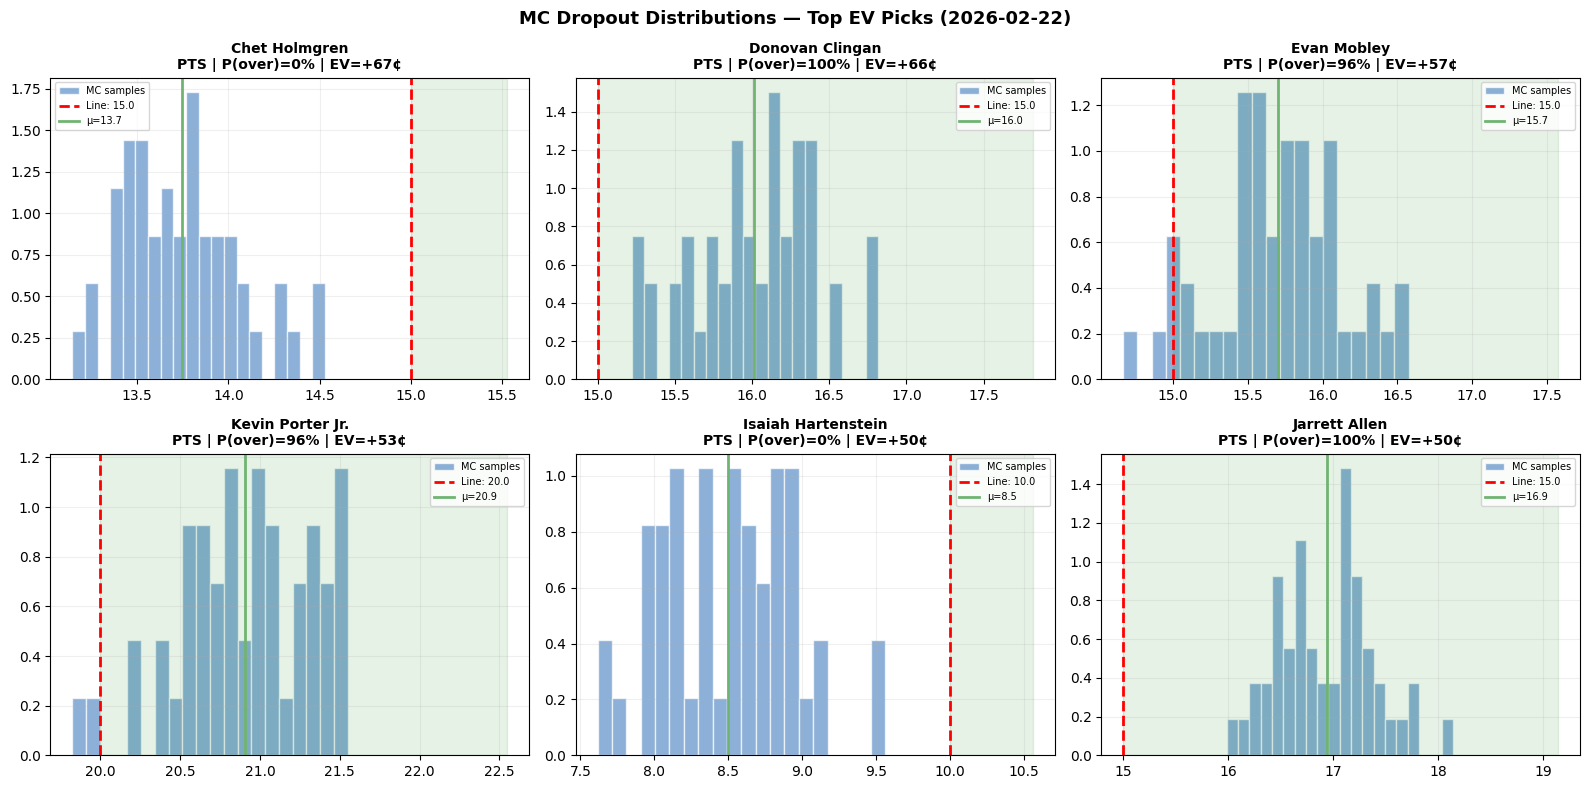

Saved ev_distributions_2026-02-22.png

── Model Edge by Stat ──
  PTS: avg_edge=-0.138  avg_EV_yes=-13.8¢  avg_EV_no=-15.1¢  positive_EV=91/152


In [18]:
# ═══════════════════════════════════════════════════════════════
# MC Dropout: Run 50 stochastic forward passes
# ═══════════════════════════════════════════════════════════════
N_MC = 50  # Number of MC samples (50 gives good coverage)

today_str = date.today().isoformat()
pregame_path = TRACKING_DIR / f'pregame_{today_str}.json'

if not pregame_path.exists():
    print(f'No pre-game file for {today_str}. Run Cell 10 first.')
else:
    with open(pregame_path) as f:
        predictions = json.load(f)
    
    if not predictions:
        print('No predictions found in pre-game file.')
    else:
        print(f'Running {N_MC} MC Dropout passes for uncertainty estimation…')
        
        latest_day_idx = len(game_dates) - 1
        input_days = list(range(latest_day_idx - SEQ_LENGTH + 1, latest_day_idx + 1))
        g_window = G_edges[latest_day_idx - SEQ_LENGTH + 1:latest_day_idx + 1]
        
        mu_d = mu_per_day[latest_day_idx, 0, PRED_INDICES]
        sd_d = sd_per_day[latest_day_idx, 0, PRED_INDICES]
        
        model.train()   # ← Enable dropout for stochastic inference
        team_emb.eval(); pos_emb.eval()  # Keep embeddings deterministic
        
        mc_samples = []  # will be (N_MC, N_players, 6)
        for mc_i in range(N_MC):
            with torch.no_grad():
                Xl = []
                for t_step, abs_day in enumerate(input_days):
                    tv = team_emb(team_temporal_t[abs_day])
                    pv = pos_emb(pos_temporal_t[abs_day])
                    Xl.append(torch.cat([
                        torch.FloatTensor(X_seq[abs_day]).to(DEVICE), tv, pv], 1))
                x = torch.stack(Xl, -1)[None, ...]
                p_z = model(x, g_window)[0].cpu().numpy()  # (N, 6) Z-space
                p_raw = p_z * sd_d + mu_d
                mc_samples.append(p_raw)
        
        model.eval()  # Restore eval mode
        mc_samples = np.stack(mc_samples)  # (N_MC, N_players, 6)
        print(f'MC samples shape: {mc_samples.shape}')
        
        # ─── Build EV table ──────────────────────────────────────
        name2pidx_ev = {}
        raw_ref = raw_df if 'raw_df_updated' not in dir() else raw_df_updated
        for pid in player_ids:
            rows = raw_ref[raw_ref['PLAYER_ID'] == pid]
            if len(rows):
                name2pidx_ev[norm(rows.iloc[0]['PLAYER_NAME'])] = player_ids.index(pid)
        
        ev_rows = []
        for pred in predictions:
            pname_norm = norm(pred['player'])
            pidx = name2pidx_ev.get(pname_norm)
            if pidx is None:
                continue
            stat = pred['stat']
            if stat not in STAT_TO_PRED_IDX:
                continue
            si = STAT_TO_PRED_IDX[stat]
            
            # Get MC distribution for this player+stat
            mc_dist = mc_samples[:, pidx, si]  # (N_MC,)
            threshold = pred['threshold']
            
            # P(over) = fraction of MC samples exceeding threshold
            p_over = float((mc_dist >= threshold).mean())
            p_under = 1.0 - p_over
            
            # Distribution stats
            mc_mean = float(mc_dist.mean())
            mc_std = float(mc_dist.std())
            mc_q10 = float(np.percentile(mc_dist, 10))
            mc_q90 = float(np.percentile(mc_dist, 90))
            
            # Kalshi prices (in cents)
            yes_ask = pred.get('yes_ask') or 0
            no_ask = pred.get('no_ask') or 0
            
            # EV calculation (in cents per $1 contract)
            # Buy YES: pay yes_ask, receive 100 if over, 0 if under
            ev_yes = p_over * (100 - yes_ask) - p_under * yes_ask if yes_ask > 0 else None
            # Buy NO: pay no_ask, receive 100 if under, 0 if over
            ev_no = p_under * (100 - no_ask) - p_over * no_ask if no_ask > 0 else None
            
            # Kalshi implied probability (from ask prices)
            impl_over = yes_ask / 100 if yes_ask else None
            impl_under = no_ask / 100 if no_ask else None
            
            # Edge = model probability vs market implied
            edge_over = (p_over - impl_over) if impl_over else None
            edge_under = (p_under - impl_under) if impl_under else None
            
            # Best action: which side has higher EV?
            if ev_yes is not None and ev_no is not None:
                if ev_yes >= ev_no and ev_yes > 0:
                    best_action = 'BUY YES (Over)'
                    best_ev = ev_yes
                elif ev_no > ev_yes and ev_no > 0:
                    best_action = 'BUY NO (Under)'
                    best_ev = ev_no
                else:
                    best_action = 'NO EDGE'
                    best_ev = max(ev_yes, ev_no)
            else:
                best_action = 'N/A'
                best_ev = 0
            
            ev_rows.append({
                'player': pred['player'],
                'stat': stat,
                'game': pred.get('game', ''),
                'threshold': threshold,
                'mc_mean': round(mc_mean, 1),
                'mc_std': round(mc_std, 2),
                'mc_q10_q90': f'{mc_q10:.1f}–{mc_q90:.1f}',
                'p_over': round(p_over, 3),
                'p_under': round(p_under, 3),
                'yes_ask': yes_ask,
                'no_ask': no_ask,
                'impl_over': round(impl_over, 3) if impl_over else None,
                'ev_yes_cents': round(ev_yes, 1) if ev_yes is not None else None,
                'ev_no_cents': round(ev_no, 1) if ev_no is not None else None,
                'edge_over': round(edge_over, 3) if edge_over is not None else None,
                'best_action': best_action,
                'best_ev': round(best_ev, 1) if best_ev else 0,
                'recent_5d': pred.get('recent_games_5d', '?'),
            })
        
        df_ev = pd.DataFrame(ev_rows)
        
        # ─── Save full EV analysis ──────────────────────────────
        ev_path = TRACKING_DIR / f'ev_analysis_{today_str}.json'
        with open(ev_path, 'w') as f:
            json.dump(ev_rows, f, indent=2)
        print(f'Saved full EV analysis → {ev_path}')
        
        # ─── Display: Top EV opportunities ──────────────────────
        print(f'\n{"═" * 70}')
        print(f'  TOP POSITIVE-EV OPPORTUNITIES  ({today_str})')
        print(f'{"═" * 70}')
        
        pos_ev = df_ev[df_ev['best_ev'] > 0].sort_values('best_ev', ascending=False)
        if len(pos_ev) > 0:
            display_cols = ['player', 'stat', 'threshold', 'mc_mean', 'mc_std',
                           'mc_q10_q90', 'p_over', 'yes_ask', 'no_ask',
                           'ev_yes_cents', 'ev_no_cents', 'best_action', 'best_ev',
                           'recent_5d']
            display(pos_ev[display_cols].head(20))
        else:
            print('No positive-EV opportunities found.')
        
        print(f'\n── Summary ──')
        print(f'Total props analyzed: {len(df_ev)}')
        print(f'Positive EV (YES): {(df_ev["ev_yes_cents"] > 0).sum()}')
        print(f'Positive EV (NO):  {(df_ev["ev_no_cents"] > 0).sum()}')
        print(f'No edge:           {(df_ev["best_ev"] <= 0).sum()}')
        
        # ─── Confidence analysis ────────────────────────────────
        print(f'\n{"═" * 70}')
        print(f'  CONFIDENCE ANALYSIS')
        print(f'{"═" * 70}')
        
        # High-confidence = large edge + low MC std + recent data
        if len(pos_ev) > 0:
            hc = pos_ev[
                (pos_ev['mc_std'] < pos_ev['mc_std'].median()) &
                (pos_ev['best_ev'] > pos_ev['best_ev'].median())
            ].copy()
            if 'recent_5d' in hc.columns:
                hc = hc[hc['recent_5d'] >= 2]  # Player has recent data
            if len(hc) > 0:
                print(f'\n🎯 HIGH CONFIDENCE picks: (low MC std + high EV + recent data)')
                display(hc[display_cols])
            else:
                print('No high-confidence picks meet all criteria.')
        
        # ─── Distribution visualization for top picks ───────────
        top_picks = pos_ev.head(6)
        if len(top_picks) > 0:
            n_plots = min(len(top_picks), 6)
            fig, axes = plt.subplots(2, 3, figsize=(16, 8))
            axes_flat = axes.ravel()
            
            for idx, (_, row) in enumerate(top_picks.head(n_plots).iterrows()):
                ax = axes_flat[idx]
                pidx = name2pidx_ev.get(norm(row['player']))
                si = STAT_TO_PRED_IDX[row['stat']]
                dist = mc_samples[:, pidx, si]
                
                ax.hist(dist, bins=20, color='#5b8fc7', alpha=0.7, edgecolor='white',
                        density=True, label='MC samples')
                ax.axvline(row['threshold'], color='red', ls='--', lw=2,
                           label=f'Line: {row["threshold"]}')
                ax.axvline(dist.mean(), color='#70b472', ls='-', lw=2,
                           label=f'μ={dist.mean():.1f}')
                
                # Shade the over region
                ax.axvspan(row['threshold'], dist.max() + 1, alpha=0.1, color='green')
                
                ax.set_title(f'{row["player"]}\n{row["stat"]} | '
                             f'P(over)={row["p_over"]:.0%} | '
                             f'EV={row["best_ev"]:+.0f}¢',
                             fontsize=10, fontweight='bold')
                ax.legend(fontsize=7)
                ax.grid(alpha=0.2)
            
            # Hide unused axes
            for idx in range(n_plots, 6):
                axes_flat[idx].set_visible(False)
            
            plt.suptitle(f'MC Dropout Distributions — Top EV Picks ({today_str})',
                         fontweight='bold', fontsize=13)
            plt.tight_layout()
            plt.savefig(FIG_DIR / f'ev_distributions_{today_str}.png',
                        dpi=150, bbox_inches='tight')
            plt.show()
            print(f'Saved ev_distributions_{today_str}.png')
        
        # ─── Edge-by-stat breakdown ─────────────────────────────
        if 'edge_over' in df_ev.columns:
            print(f'\n── Model Edge by Stat ──')
            for stat in ['PTS', 'AST', 'REB']:
                sub = df_ev[df_ev['stat'] == stat]
                if len(sub) == 0:
                    continue
                avg_edge = sub['edge_over'].dropna().mean()
                avg_ev_yes = sub['ev_yes_cents'].dropna().mean()
                avg_ev_no = sub['ev_no_cents'].dropna().mean()
                n_pos = (sub['best_ev'] > 0).sum()
                print(f'  {stat}: avg_edge={avg_edge:+.3f}  '
                      f'avg_EV_yes={avg_ev_yes:+.1f}¢  '
                      f'avg_EV_no={avg_ev_no:+.1f}¢  '
                      f'positive_EV={n_pos}/{len(sub)}')


## 14 · Filtered Bet Sheet

Filters down to **actionable picks only** — positive EV above a safety margin.
Adjust `MIN_EV` to be more or less aggressive.


In [20]:
# ═══════════════════════════════════════════════════════════════
# CONFIGURATION — adjust these thresholds to your risk tolerance
# ═══════════════════════════════════════════════════════════════
MIN_EV         = 5.0   # Minimum EV in cents (margin of safety)
MIN_RECENT     = 2     # Player must have played ≥ this many of last 5 days
MAX_MC_STD     = None  # Set e.g. 3.0 to exclude high-uncertainty picks (None = no filter)
MIN_EDGE       = 0.05  # Minimum edge (model prob minus implied prob)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

today_str = date.today().isoformat()
ev_path = TRACKING_DIR / f'ev_analysis_{today_str}.json'

if not ev_path.exists():
    print(f'No EV analysis found for {today_str}. Run Cell 13 first.')
else:
    with open(ev_path) as f:
        ev_rows = json.load(f)
    df_ev = pd.DataFrame(ev_rows)
    
    # ── Apply filters ──
    mask = df_ev['best_ev'] >= MIN_EV
    if MIN_RECENT is not None:
        mask &= df_ev['recent_5d'] >= MIN_RECENT
    if MAX_MC_STD is not None:
        mask &= df_ev['mc_std'] <= MAX_MC_STD
    if MIN_EDGE is not None:
        edge_check = (
            (df_ev['best_action'].str.contains('YES') & (df_ev['edge_over'] >= MIN_EDGE)) |
            (df_ev['best_action'].str.contains('NO') & (df_ev['edge_over'] <= -MIN_EDGE))
        )
        mask &= edge_check
    
    filtered = df_ev[mask].sort_values('best_ev', ascending=False).copy()
    
    print(f'Filters: EV ≥ {MIN_EV}¢  |  recent ≥ {MIN_RECENT}d  |  '
          f'edge ≥ {MIN_EDGE}  |  max_std = {MAX_MC_STD or "any"}')
    print(f'Passed: {len(filtered)} / {len(df_ev)} props\n')

    if len(filtered) == 0:
        print('No bets pass the filters. Try lowering MIN_EV or MIN_EDGE.')
    else:
        # ── Display the bet sheet ──
        sheet_cols = ['player', 'stat', 'threshold', 'mc_mean', 'mc_std',
                      'p_over', 'yes_ask', 'no_ask', 'best_action',
                      'best_ev', 'edge_over', 'game']
        display(filtered[sheet_cols])
        
        # ── Quick stats ──
        n_yes = filtered['best_action'].str.contains('YES').sum()
        n_no  = filtered['best_action'].str.contains('NO').sum()
        avg_ev = filtered['best_ev'].mean()
        total_ev = filtered['best_ev'].sum()
        print(f'\n── Bet Sheet Summary ──')
        print(f'  {n_yes} OVER bets  |  {n_no} UNDER bets')
        print(f'  Avg EV per bet:   {avg_ev:+.1f}¢')
        print(f'  Total EV (all):   {total_ev:+.1f}¢')
        print(f'  If betting $1 each: ${total_ev/100:.2f} expected edge')
        
        # ── Save the filtered sheet ──
        sheet_path = TRACKING_DIR / f'bet_sheet_{today_str}.json'
        filtered.to_json(sheet_path, orient='records', indent=2)
        print(f'\n  Saved → {sheet_path}')


Filters: EV ≥ 5.0¢  |  recent ≥ 2d  |  edge ≥ 0.05  |  max_std = any
Passed: 77 / 152 props



,player,stat,threshold,mc_mean,mc_std,p_over,yes_ask,no_ask,best_action,best_ev,edge_over,game
129,Chet Holmgren,PTS,15.0,13.7,0.32,0.00,72,33,BUY NO (Under),67.0,-0.72,Cleveland at Oklahoma City: Points
30,Donovan Clingan,PTS,15.0,16.0,0.39,1.00,34,100,BUY YES (Over),66.0,0.66,Portland at Phoenix: Points
111,Kevin Porter Jr.,PTS,20.0,20.9,0.42,0.96,43,58,BUY YES (Over),53.0,0.53,Toronto at Milwaukee: Points
137,Jarrett Allen,PTS,15.0,16.9,0.45,1.00,50,55,BUY YES (Over),50.0,0.50,Cleveland at Oklahoma City: Points
130,Isaiah Hartenstein,PTS,10.0,8.5,0.44,0.00,54,50,BUY NO (Under),50.0,-0.54,Cleveland at Oklahoma City: Points
39,Karl-Anthony Towns,PTS,20.0,17.2,0.41,0.00,57,51,BUY NO (Under),49.0,-0.57,New York at Chicago: Points
122,RJ Barrett,PTS,20.0,15.8,0.41,0.00,48,56,BUY NO (Under),44.0,-0.48,Toronto at Milwaukee: Points
128,Donovan Mitchell,PTS,25.0,26.3,0.46,1.00,57,45,BUY YES (Over),43.0,0.43,Cleveland at Oklahoma City: Points
135,Chet Holmgren,PTS,20.0,13.7,0.32,0.00,45,58,BUY NO (Under),42.0,-0.45,Cleveland at Oklahoma City: Points
132,James Harden,PTS,20.0,19.3,0.39,0.04,48,54,BUY NO (Under),42.0,-0.44,Cleveland at Oklahoma City: Points



── Bet Sheet Summary ──
  42 OVER bets  |  35 UNDER bets
  Avg EV per bet:   +23.3¢
  Total EV (all):   +1794.0¢
  If betting $1 each: $17.94 expected edge

  Saved → /Users/ehfurgeson/Documents/GitHub/knowball/networks/ballnet/outputs/tracking/bet_sheet_2026-02-22.json


---

## ✅ All Done!

**Daily workflow:**

1. **Before games** → Run Cells 1–9 (one-time setup), then Cell 10 (fetch data + Kalshi + inference)
2. **EV Analysis** → Run Cell 13 (MC Dropout + EV ranking)
3. **Bet Sheet** → Run Cell 14 (filtered picks only)
4. **After games** → Run Cell 11 (grade results vs. settled markets)
5. **Anytime** → Run Cell 12 (lifetime dashboard)

**Data files:**
- `outputs/tracking/pregame_YYYY-MM-DD.json` — Pre-game predictions
- `outputs/tracking/ev_analysis_YYYY-MM-DD.json` — MC Dropout EV analysis
- `outputs/tracking/bet_sheet_YYYY-MM-DD.json` — Filtered actionable picks
- `outputs/tracking/results_log.jsonl` — Cumulative graded results
